---
title: Motion Estimation
sidebarTitle: Motion Estimation
description: Motion estimation from intuition to implementation using synthetic image pairs, patch matching, sparse motion fields, and failure analysis.
---


# Motion estimation

Motion estimation asks a simple question: if something moves between two frames, can we recover **where it went**?

In this notebook we will:

- build intuition for motion in image coordinates,
- recover motion with a readable patch-matching baseline,
- estimate a sparse motion field on synthetic data with known ground truth,
- quantify accuracy with endpoint error and match ratios,
- study how patch size, search radius, and noise change the results,
- and inspect failure modes that motivate more advanced optical-flow methods.

The goal is not to be fancy. The goal is to make the core idea visible and trustworthy.


## Intuition

Between two video frames, a moving object often keeps a similar local appearance.
That means a small patch around a point in Frame 1 may reappear a few pixels away in Frame 2.

We will use the image-coordinate convention common in vision:

- $x$ increases to the **right**,
- $y$ increases **downward**,
- a motion vector is written as $(dx, dy)$.

So $(dx=5, dy=-4)$ means "move 5 pixels right and 4 pixels up."

The figure below is generated directly from the synthetic frames used throughout the notebook.
Notice the three key landmarks: the source patch in Frame 1, the true target in Frame 2, and the estimated target recovered by local patch matching.
Because this example uses a known translation, we can check whether the visual displacement and the recovered motion agree exactly.


## Imports, plotting style, and figure output

The notebook uses only `numpy` and `matplotlib`. A fixed random seed keeps the synthetic examples reproducible.
Important executable figures are also written to `images/` during notebook execution so the same run produces both inline notebook outputs and standalone figure files.


In [1]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle

plt.style.use("default")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f7f8f4",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "figure.titlesize": 15,
    }
)

FIGURE_DIR = Path("images")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename, dpi=200):
    output_path = FIGURE_DIR / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight", pad_inches=0.12)
    return output_path


rng = np.random.default_rng(7)


## Synthetic example setup

We start with clean synthetic frames because the true motion is known exactly.
That lets us debug the estimator before dealing with real video.

The scene uses a few textured geometric shapes so patch matching has enough visual structure to lock onto.


The helper below builds a frame pair with a known integer translation.
We will display a single polished motion-intuition figure later, once the patch matcher has also produced the estimated target.


In [2]:
def normalize_image(img):
    return np.clip(img, 0.0, 1.0)


def add_rectangle(img, x0, y0, w, h, base=0.75, texture="flat"):
    yy, xx = np.mgrid[y0 : y0 + h, x0 : x0 + w]
    patch = np.full((h, w), base, dtype=float)
    if texture == "gradient":
        patch *= 0.55 + 0.45 * (xx - x0) / max(w - 1, 1)
    elif texture == "checker":
        patch *= 0.65 + 0.35 * (((xx - x0) // 4 + (yy - y0) // 4) % 2)
    img[y0 : y0 + h, x0 : x0 + w] = np.maximum(img[y0 : y0 + h, x0 : x0 + w], patch)


def add_disk(img, cx, cy, radius, base=0.82):
    yy, xx = np.mgrid[: img.shape[0], : img.shape[1]]
    dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    mask = dist <= radius
    ripple = 0.78 + 0.22 * np.cos(dist[mask] / max(radius, 1) * np.pi)
    img[mask] = np.maximum(img[mask], base * ripple)


def shift_image_integer(img, dx, dy, fill_value=0.06):
    shifted = np.full_like(img, fill_value)
    h, w = img.shape

    src_x0 = max(0, -dx)
    src_x1 = min(w, w - dx)
    src_y0 = max(0, -dy)
    src_y1 = min(h, h - dy)

    dst_x0 = max(0, dx)
    dst_x1 = dst_x0 + (src_x1 - src_x0)
    dst_y0 = max(0, dy)
    dst_y1 = dst_y0 + (src_y1 - src_y0)

    if src_x1 > src_x0 and src_y1 > src_y0:
        shifted[dst_y0:dst_y1, dst_x0:dst_x1] = img[src_y0:src_y1, src_x0:src_x1]
    return shifted


def make_synthetic_pair(dx=5, dy=-4, noise_std=0.0, size=96, seed=None):
    frame1 = np.full((size, size), 0.06, dtype=float)
    add_rectangle(frame1, 14, 18, 24, 20, base=0.88, texture="gradient")
    add_rectangle(frame1, 52, 14, 22, 26, base=0.82, texture="checker")
    add_rectangle(frame1, 22, 62, 28, 12, base=0.70, texture="checker")
    add_disk(frame1, 68, 66, 11, base=0.95)

    frame2 = shift_image_integer(frame1, dx=dx, dy=dy, fill_value=0.06)

    local_rng = np.random.default_rng(seed) if seed is not None else rng
    if noise_std > 0:
        frame1 = normalize_image(frame1 + local_rng.normal(0.0, noise_std, frame1.shape))
        frame2 = normalize_image(frame2 + local_rng.normal(0.0, noise_std, frame2.shape))

    return frame1, frame2, np.array([dx, dy], dtype=int)


def motion_to_index(dx, dy, search_radius):
    return dx + search_radius, dy + search_radius


def draw_displacement_arrow(ax, start_xy, end_xy, color, label, text_offset=(2, -5), linestyle="-"):
    arrow = FancyArrowPatch(
        start_xy,
        end_xy,
        arrowstyle="-|>",
        mutation_scale=12,
        linewidth=2.0,
        color=color,
        linestyle=linestyle,
        shrinkA=3,
        shrinkB=3,
    )
    ax.add_patch(arrow)
    mid_x = 0.5 * (start_xy[0] + end_xy[0]) + text_offset[0]
    mid_y = 0.5 * (start_xy[1] + end_xy[1]) + text_offset[1]
    ax.text(
        mid_x,
        mid_y,
        label,
        color=color,
        fontsize=9.4,
        weight="bold",
        bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.9),
    )


def show_frame_pair(frame1, frame2, gt_motion, point_xy=None, patch_size=None, estimated_motion=None, save_name=None):
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.4), constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.04, h_pad=0.08, hspace=0.05, wspace=0.08)
    motion_tuple = tuple(map(int, gt_motion))

    for ax, image, title in zip(axes, [frame1, frame2], ["Frame 1", "Frame 2"]):
        ax.imshow(image, cmap="gray", vmin=0, vmax=1, origin="upper")
        ax.set_title(title, pad=12)
        ax.set_xticks([])
        ax.set_yticks([])

    if point_xy is not None and patch_size is not None:
        radius = patch_size // 2
        query_color = "#2f6173"
        true_color = "#d4553b"
        est_color = "#2f7f57"
        true_xy = (point_xy[0] + motion_tuple[0], point_xy[1] + motion_tuple[1])

        axes[0].add_patch(
            Rectangle((point_xy[0] - radius, point_xy[1] - radius), patch_size, patch_size,
                      edgecolor=query_color, facecolor="none", linewidth=2.3)
        )
        axes[0].scatter(*point_xy, s=42, color=query_color, zorder=4)
        axes[0].text(
            point_xy[0] - radius,
            point_xy[1] - radius - 6,
            "query patch",
            color=query_color,
            fontsize=9.8,
            weight="bold",
            bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.9),
        )
        axes[0].text(
            point_xy[0] + 5,
            point_xy[1] + radius + 8,
            "source center",
            color=query_color,
            fontsize=9.2,
            bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.9),
        )

        axes[1].add_patch(
            Rectangle((true_xy[0] - radius, true_xy[1] - radius), patch_size, patch_size,
                      edgecolor=true_color, facecolor="none", linewidth=2.4)
        )
        axes[1].scatter(*true_xy, s=48, color=true_color, zorder=5)
        axes[1].text(
            true_xy[0] - radius,
            true_xy[1] - radius - 6,
            "true target",
            color=true_color,
            fontsize=9.8,
            weight="bold",
            bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.92),
        )
        draw_displacement_arrow(
            axes[1],
            point_xy,
            true_xy,
            true_color,
            f"true shift (dx={motion_tuple[0]}, dy={motion_tuple[1]})",
            text_offset=(1, -8),
        )

        if estimated_motion is not None:
            est_xy = (point_xy[0] + int(estimated_motion[0]), point_xy[1] + int(estimated_motion[1]))
            axes[1].scatter(*est_xy, s=72, marker="x", color=est_color, linewidths=2.2, zorder=6)
            if est_xy != true_xy:
                axes[1].add_patch(
                    Rectangle((est_xy[0] - radius, est_xy[1] - radius), patch_size, patch_size,
                              edgecolor=est_color, facecolor="none", linewidth=2.0, linestyle="--")
                )
            axes[1].text(
                est_xy[0] + 2,
                est_xy[1] + radius + 8,
                f"estimated (dx={int(estimated_motion[0])}, dy={int(estimated_motion[1])})",
                color=est_color,
                fontsize=9.2,
                weight="bold",
                bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.9),
            )

    fig.suptitle(
        f"Motion intuition from executable synthetic frames: translation = (dx={motion_tuple[0]}, dy={motion_tuple[1]})",
        y=1.03,
        fontsize=15,
    )
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


demo_point_xy = (72, 64)
demo_patch_size = 11
frame1, frame2, gt_motion = make_synthetic_pair(dx=5, dy=-4, noise_std=0.015, seed=7)
demo_match = None


## Patch matching / local search

The baseline method is deliberately simple:

1. extract an odd-sized patch around a point in Frame 1,
2. search a square window around the same location in Frame 2,
3. score each candidate with SSD (sum of squared differences),
4. keep the displacement with the lowest score.

This is easy to read and easy to reason about, which makes it a good teaching baseline.
The executable diagnostic figure below shows the full loop in one place: source patch, searched region, SSD surface, matched patch, and patch error.


The next cell defines reusable helpers for patch extraction, SSD scoring, exhaustive local search, and patch-match visualization.


In [3]:
def extract_patch(image, center_xy, patch_size):
    radius = patch_size // 2
    x, y = map(int, center_xy)
    if x - radius < 0 or y - radius < 0:
        return None
    if x + radius >= image.shape[1] or y + radius >= image.shape[0]:
        return None
    return image[y - radius : y + radius + 1, x - radius : x + radius + 1]


def ssd_cost(template, candidate):
    diff = template - candidate
    return float(np.sum(diff * diff))


def filter_trackable_points(points, image_shape, patch_size, search_radius):
    radius = patch_size // 2 + search_radius
    height, width = image_shape
    valid_points = []
    for x, y in points:
        if radius <= x < width - radius and radius <= y < height - radius:
            valid_points.append((x, y))
    return valid_points


def estimate_patch_motion(frame1, frame2, point_xy, patch_size=11, search_radius=8):
    template = extract_patch(frame1, point_xy, patch_size)
    if template is None:
        raise ValueError("Source patch falls outside the image.")

    costs = np.full((2 * search_radius + 1, 2 * search_radius + 1), np.inf)
    best = {"cost": np.inf, "dx": 0, "dy": 0, "match_patch": None, "best_point": point_xy}

    for row, dy in enumerate(range(-search_radius, search_radius + 1)):
        for col, dx in enumerate(range(-search_radius, search_radius + 1)):
            candidate_point = (point_xy[0] + dx, point_xy[1] + dy)
            candidate = extract_patch(frame2, candidate_point, patch_size)
            if candidate is None:
                continue
            cost = ssd_cost(template, candidate)
            costs[row, col] = cost
            if cost < best["cost"]:
                best = {
                    "cost": cost,
                    "dx": dx,
                    "dy": dy,
                    "match_patch": candidate,
                    "best_point": candidate_point,
                }

    best["template_patch"] = template
    best["cost_map"] = costs
    return best


def draw_patch_matching_diagnostic(
    frame1,
    frame2,
    point_xy,
    gt_motion,
    match_result,
    patch_size,
    search_radius,
    title,
    save_name=None,
    note=None,
):
    radius = patch_size // 2
    x, y = point_xy
    gt_dx, gt_dy = map(int, gt_motion)
    true_x, true_y = x + gt_dx, y + gt_dy
    best_x, best_y = match_result["best_point"]
    best_dx, best_dy = match_result["dx"], match_result["dy"]
    true_in_window = abs(gt_dx) <= search_radius and abs(gt_dy) <= search_radius

    patch_vmin = min(match_result["template_patch"].min(), match_result["match_patch"].min())
    patch_vmax = max(match_result["template_patch"].max(), match_result["match_patch"].max())
    patch_error = np.abs(match_result["template_patch"] - match_result["match_patch"])

    fig = plt.figure(figsize=(15.6, 9.4), constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.04, h_pad=0.1, hspace=0.1, wspace=0.08)
    gs = fig.add_gridspec(2, 3, height_ratios=[1.12, 0.88])
    axes = np.array(
        [
            [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])],
            [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2])],
        ]
    )

    axes[0, 0].imshow(frame1, cmap="gray", vmin=0, vmax=1, origin="upper")
    axes[0, 0].add_patch(
        Rectangle((x - radius, y - radius), patch_size, patch_size, edgecolor="#2f6173", facecolor="none", linewidth=2.5)
    )
    axes[0, 0].scatter(x, y, s=38, color="#2f6173", zorder=4)
    axes[0, 0].set_title("Frame 1: query patch", pad=10)
    axes[0, 0].set_xticks([])
    axes[0, 0].set_yticks([])

    axes[0, 1].imshow(frame2, cmap="gray", vmin=0, vmax=1, origin="upper")
    axes[0, 1].add_patch(
        Rectangle(
            (x - search_radius - radius, y - search_radius - radius),
            2 * search_radius + patch_size,
            2 * search_radius + patch_size,
            edgecolor="#7a4f9a",
            facecolor="none",
            linewidth=2.2,
            linestyle="--",
        )
    )
    axes[0, 1].add_patch(
        Rectangle((best_x - radius, best_y - radius), patch_size, patch_size, edgecolor="#d4553b", facecolor="none", linewidth=2.5)
    )
    axes[0, 1].scatter(best_x, best_y, s=48, color="#d4553b", zorder=6)
    axes[0, 1].scatter(true_x, true_y, s=88, marker="x", color="#2f8a52", linewidths=2.6, zorder=7)
    axes[0, 1].set_title("Frame 2: search window and targets", pad=10)
    axes[0, 1].set_xticks([])
    axes[0, 1].set_yticks([])

    frame2_handles = [
        plt.Line2D([0], [0], color="#7a4f9a", linestyle="--", linewidth=2.2, label="search window"),
        plt.Line2D([0], [0], color="#d4553b", marker="s", markersize=8, fillstyle="none", linewidth=0, label="estimated match"),
        plt.Line2D([0], [0], color="#2f8a52", marker="x", markersize=9, linewidth=0, label="true target"),
    ]
    axes[0, 1].legend(
        handles=frame2_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=3,
        frameon=False,
        fontsize=10.2,
        columnspacing=1.8,
        handletextpad=0.5,
    )

    extent = [-search_radius - 0.5, search_radius + 0.5, -search_radius - 0.5, search_radius + 0.5]
    im = axes[0, 2].imshow(match_result["cost_map"], cmap="magma_r", origin="lower", extent=extent, aspect="equal")
    axes[0, 2].scatter(
        best_dx,
        best_dy,
        s=110,
        facecolors="white",
        edgecolors="#1f2933",
        linewidths=1.4,
        zorder=5,
        label="estimated minimum",
    )
    if true_in_window:
        axes[0, 2].scatter(gt_dx, gt_dy, s=118, marker="x", color="#2f8a52", linewidths=2.6, zorder=6, label="true motion")
    else:
        axes[0, 2].text(
            0.02,
            0.04,
            "True motion is outside the searched displacement range.",
            transform=axes[0, 2].transAxes,
            ha="left",
            va="bottom",
            fontsize=9.6,
            color="#2f8a52",
            bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="none", alpha=0.9),
        )
    axes[0, 2].set_title("SSD cost over candidate displacements", pad=10)
    axes[0, 2].set_xlabel("dx (pixels)")
    axes[0, 2].set_ylabel("dy (pixels)")
    axes[0, 2].set_xticks(np.arange(-search_radius, search_radius + 1, 2))
    axes[0, 2].set_yticks(np.arange(-search_radius, search_radius + 1, 2))
    axes[0, 2].legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2, frameon=False, fontsize=10.0)
    cbar = fig.colorbar(im, ax=axes[0, 2], fraction=0.046, pad=0.03)
    cbar.set_label("SSD cost")

    axes[1, 0].imshow(match_result["template_patch"], cmap="gray", vmin=patch_vmin, vmax=patch_vmax)
    axes[1, 0].set_title("Source patch", pad=10)
    axes[1, 1].imshow(match_result["match_patch"], cmap="gray", vmin=patch_vmin, vmax=patch_vmax)
    axes[1, 1].set_title("Matched patch", pad=10)
    err_im = axes[1, 2].imshow(patch_error, cmap="viridis", vmin=0, vmax=max(patch_error.max(), 1e-6))
    axes[1, 2].set_title("Absolute patch error", pad=10)
    err_cbar = fig.colorbar(err_im, ax=axes[1, 2], fraction=0.046, pad=0.03)
    err_cbar.set_label("|source - match|")

    for ax in axes[1]:
        ax.set_xticks([])
        ax.set_yticks([])

    print(f"{title}: estimated = ({best_dx}, {best_dy}), true = ({gt_dx}, {gt_dy}), best SSD = {match_result['cost']:.4f}")
    if note:
        print(note)
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


## Single-point motion estimation demo

We first track one carefully chosen point so every part of the process is visible.
Read the top row from left to right: the source patch in Frame 1, the searched region in Frame 2, and the SSD surface over candidate $(dx, dy)$ displacements.
Then compare the bottom-row patches: a low-error match means the winning displacement is also visually plausible.


Estimated motion at (72, 64): (dx=5, dy=-4)
Ground truth motion: (5, -4)
Best SSD cost: 0.0436


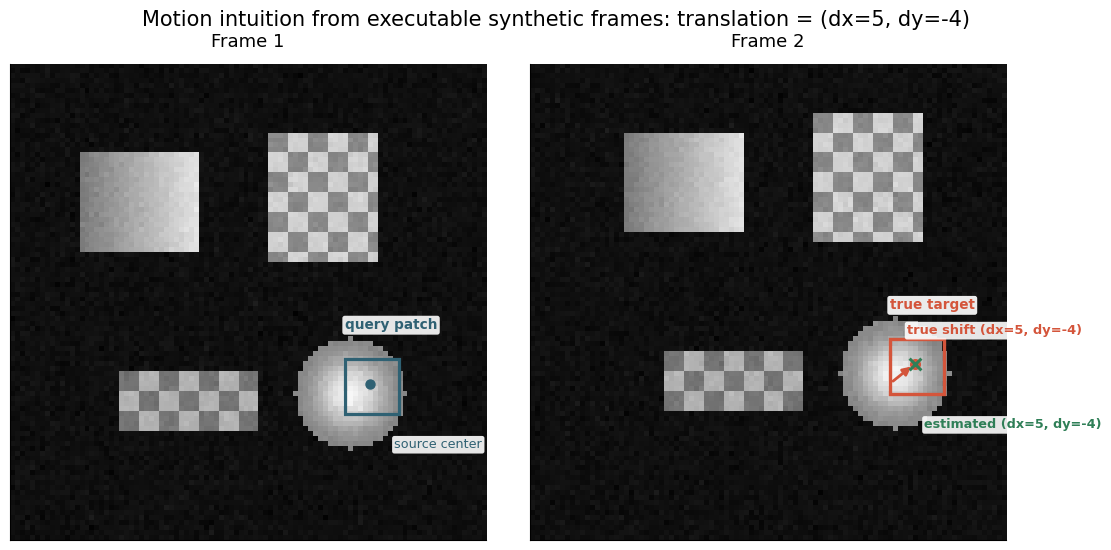

Single-point patch matching: estimated = (5, -4), true = (5, -4), best SSD = 0.0436


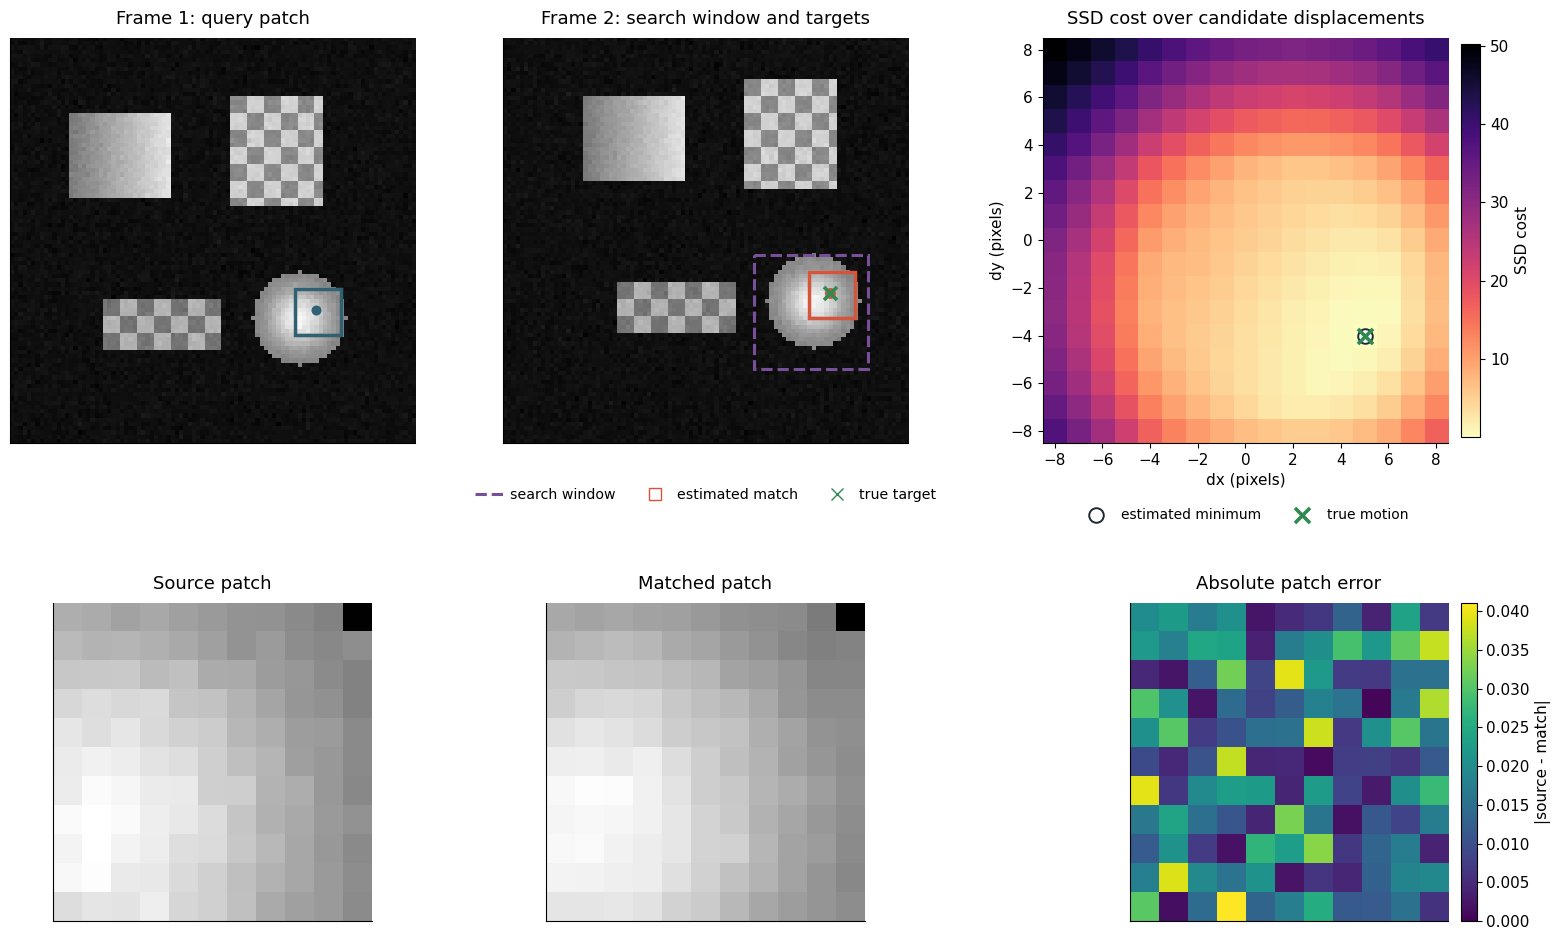

In [4]:
point_xy = demo_point_xy
patch_size = demo_patch_size
search_radius = 8

match_result = estimate_patch_motion(frame1, frame2, point_xy, patch_size=patch_size, search_radius=search_radius)
print(f"Estimated motion at {point_xy}: (dx={match_result['dx']}, dy={match_result['dy']})")
print(f"Ground truth motion: {tuple(map(int, gt_motion))}")
print(f"Best SSD cost: {match_result['cost']:.4f}")

show_frame_pair(
    frame1,
    frame2,
    gt_motion,
    point_xy=point_xy,
    patch_size=patch_size,
    estimated_motion=(match_result["dx"], match_result["dy"]),
    save_name="01-frame-pair.png",
)
draw_patch_matching_diagnostic(
    frame1,
    frame2,
    point_xy,
    gt_motion,
    match_result,
    patch_size,
    search_radius,
    title="Single-point patch matching",
    save_name="02-patch-matching-diagnostic.png",
)


## Sparse motion field estimation

One point is useful for intuition, but a motion field becomes more interesting when we estimate many arrows.
We sample textured points on a grid, run the same local matcher at each one, and compute metrics over all valid points.

To keep the figure readable, we display only a subset of arrows.
Exact estimates and mismatches are intentionally styled differently so the coherent global translation is easy to spot.


Sparse field summary: 22 points, exact = 0.95, within 1 px = 0.95, mean EPE = 0.36 px


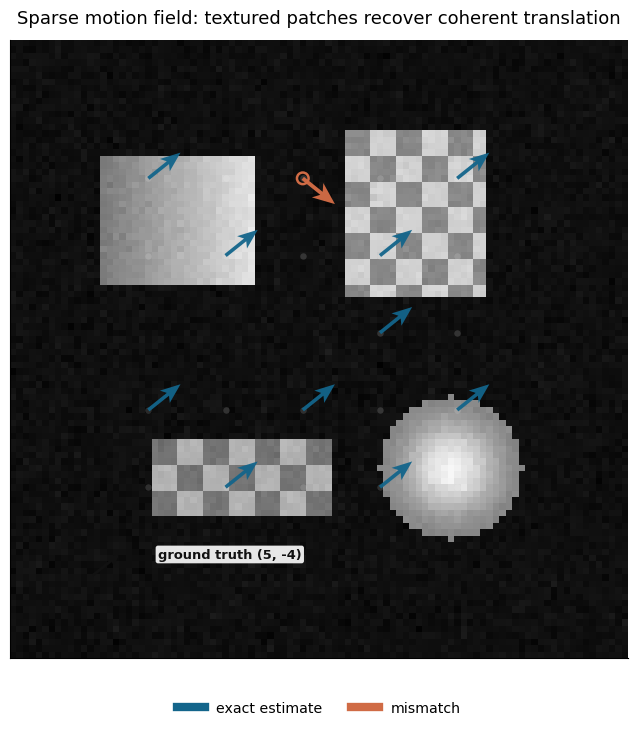

In [5]:
def sample_textured_points(frame, patch_size, stride=12, threshold=0.18):
    radius = patch_size // 2
    points = []
    for y in range(radius + 2, frame.shape[0] - radius - 2, stride):
        for x in range(radius + 2, frame.shape[1] - radius - 2, stride):
            patch = extract_patch(frame, (x, y), patch_size)
            if patch is None:
                continue
            if patch.std() > threshold or patch.mean() > 0.35:
                points.append((x, y))
    return points


def estimate_sparse_motion(frame1, frame2, points, patch_size=11, search_radius=8):
    estimates = []
    for point in points:
        result = estimate_patch_motion(frame1, frame2, point, patch_size=patch_size, search_radius=search_radius)
        estimates.append({
            "point": point,
            "dx": result["dx"],
            "dy": result["dy"],
            "cost": result["cost"],
        })
    return estimates


def summarize_motion_metrics(estimates, gt_motion):
    vectors = np.array([[item["dx"], item["dy"]] for item in estimates], dtype=float)
    gt = np.asarray(gt_motion, dtype=float)
    errors = vectors - gt[None, :]
    epe = np.sqrt(np.sum(errors ** 2, axis=1))
    exact = np.all(vectors == gt[None, :], axis=1)
    near = epe <= 1.0
    return {
        "num_points": len(estimates),
        "mean_epe": float(epe.mean()),
        "median_epe": float(np.median(epe)),
        "max_epe": float(epe.max()),
        "exact_match_ratio": float(exact.mean()),
        "within_1px_ratio": float(near.mean()),
    }


def draw_sparse_motion_field(frame, estimates, gt_motion, title, save_name=None):
    gt_dx, gt_dy = map(int, gt_motion)
    vectors = np.array([[item["dx"], item["dy"]] for item in estimates], dtype=int)
    points = np.array([item["point"] for item in estimates], dtype=int)
    exact_mask = np.all(vectors == np.array([gt_dx, gt_dy]), axis=1)
    display_mask = np.zeros(len(estimates), dtype=bool)
    display_mask[::2] = True

    fig, ax = plt.subplots(figsize=(8.1, 7.2), constrained_layout=True)
    ax.imshow(frame, cmap="gray", vmin=0, vmax=1, origin="upper")
    ax.scatter(points[:, 0], points[:, 1], s=22, color="white", alpha=0.14, linewidths=0)

    exact_display = display_mask & exact_mask
    mismatch_display = display_mask & ~exact_mask

    if np.any(exact_display):
        ax.quiver(
            points[exact_display, 0],
            points[exact_display, 1],
            vectors[exact_display, 0],
            vectors[exact_display, 1],
            color="#13658b",
            angles="xy",
            scale_units="xy",
            scale=1,
            width=0.0058,
            headwidth=4.4,
            headlength=5.6,
            alpha=0.95,
        )

    if np.any(mismatch_display):
        ax.quiver(
            points[mismatch_display, 0],
            points[mismatch_display, 1],
            vectors[mismatch_display, 0],
            vectors[mismatch_display, 1],
            color="#d06b45",
            angles="xy",
            scale_units="xy",
            scale=1,
            width=0.0062,
            headwidth=4.8,
            headlength=5.8,
            alpha=0.98,
        )
        ax.scatter(
            points[mismatch_display, 0],
            points[mismatch_display, 1],
            s=70,
            facecolors="none",
            edgecolors="#d06b45",
            linewidths=1.8,
            zorder=5,
        )

    ref_start = (12, frame.shape[0] - 13)
    ref_end = (ref_start[0] + gt_dx, ref_start[1] + gt_dy)
    draw_displacement_arrow(ax, ref_start, ref_end, "#111111", f"ground truth ({gt_dx}, {gt_dy})", text_offset=(8, -1))

    ax.set_title(title, pad=12)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(
        handles=[
            plt.Line2D([0], [0], color="#13658b", linewidth=6, label="exact estimate"),
            plt.Line2D([0], [0], color="#d06b45", linewidth=6, label="mismatch"),
        ],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=2,
        frameon=False,
        fontsize=10.2,
    )
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


field_patch_size = 15
field_threshold = 0.08
candidate_points = sample_textured_points(frame1, patch_size=field_patch_size, stride=12, threshold=field_threshold)
points = filter_trackable_points(candidate_points, frame1.shape, patch_size=field_patch_size, search_radius=8)
estimates = estimate_sparse_motion(frame1, frame2, points, patch_size=field_patch_size, search_radius=8)
summary = summarize_motion_metrics(estimates, gt_motion)
summary

print(
    f"Sparse field summary: {summary['num_points']} points, exact = {summary['exact_match_ratio']:.2f}, "
    f"within 1 px = {summary['within_1px_ratio']:.2f}, mean EPE = {summary['mean_epe']:.2f} px"
)

draw_sparse_motion_field(
    frame1,
    estimates,
    gt_motion,
    title="Sparse motion field: textured patches recover coherent translation",
    save_name="03-sparse-motion-field.png",
)


## Validation metrics

Because the synthetic translation is known, we can score the estimates directly.

- **Endpoint error (EPE)** is the Euclidean distance between the estimated vector and the true vector.
- **Exact match ratio** is the fraction of estimates that recover the exact integer motion.
- **Correct-within-1-pixel ratio** is a softer measure that counts near misses as acceptable.

These metrics answer slightly different questions, so it is helpful to look at all of them.
The figure keeps the bar charts compact, and the printed summary reports the mean EPE explicitly so the layout stays uncluttered.


            mean_epe: 0.364
          median_epe: 0.000
             max_epe: 8.000
   exact_match_ratio: 0.955
    within_1px_ratio: 0.955
Metrics summary mean EPE: 0.36 px


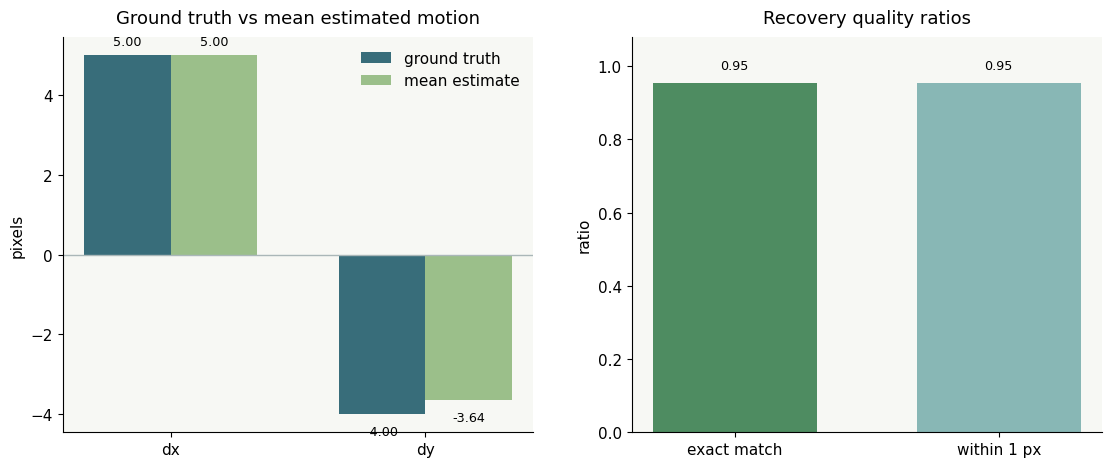

In [6]:
metric_names = ["mean_epe", "median_epe", "max_epe", "exact_match_ratio", "within_1px_ratio"]
for key in metric_names:
    print(f"{key:>20}: {summary[key]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.04, h_pad=0.06, hspace=0.04, wspace=0.08)
labels = ["dx", "dy"]
x = np.arange(len(labels))
width = 0.34
mean_estimate = np.array([
    np.mean([item["dx"] for item in estimates]),
    np.mean([item["dy"] for item in estimates]),
])

gt_bars = axes[0].bar(x - width / 2, gt_motion, width=width, color="#386d7a", label="ground truth")
est_bars = axes[0].bar(x + width / 2, mean_estimate, width=width, color="#9bbf8a", label="mean estimate")
axes[0].set_xticks(x, labels)
axes[0].set_ylabel("pixels")
axes[0].set_title("Ground truth vs mean estimated motion", pad=10)
axes[0].legend(frameon=False, loc="upper right")
axes[0].axhline(0, color="#aab7b8", linewidth=1.0)

for bars in [gt_bars, est_bars]:
    for bar in bars:
        height = bar.get_height()
        y_text = height + 0.18 if height >= 0 else height - 0.28
        va = "bottom" if height >= 0 else "top"
        axes[0].text(bar.get_x() + bar.get_width() / 2, y_text, f"{height:.2f}", ha="center", va=va, fontsize=9.2)

ratio_values = [summary["exact_match_ratio"], summary["within_1px_ratio"]]
ratio_labels = ["exact match", "within 1 px"]
ratio_bars = axes[1].bar(ratio_labels, ratio_values, color=["#4e8c61", "#88b7b5"], width=0.62)
axes[1].set_ylim(0, 1.08)
axes[1].set_ylabel("ratio")
axes[1].set_title("Recovery quality ratios", pad=10)
for bar, value in zip(ratio_bars, ratio_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value + 0.03, f"{value:.2f}", ha="center", va="bottom", fontsize=9.2)

print(f"Metrics summary mean EPE: {summary['mean_epe']:.2f} px")
save_figure(fig, "04-metrics-summary.png")
plt.show()


## Parameter sweeps / analysis

Three knobs matter immediately:

- **Patch size**: larger patches are often more stable, but they blur away local detail.
- **Search radius**: larger windows can recover larger motion, but they cost more and may invite distractors.
- **Noise level**: noisy images reduce the reliability of appearance matching.

The sweep plots below are generated from controlled synthetic experiments.
Because the true motion is $(5, -4)$, the search-radius plot can also tell us when the window first becomes large enough to contain the correct answer.
For the noise sweep, we average over multiple fixed seeds so the trend reflects the teaching point more clearly than any one noisy draw would.


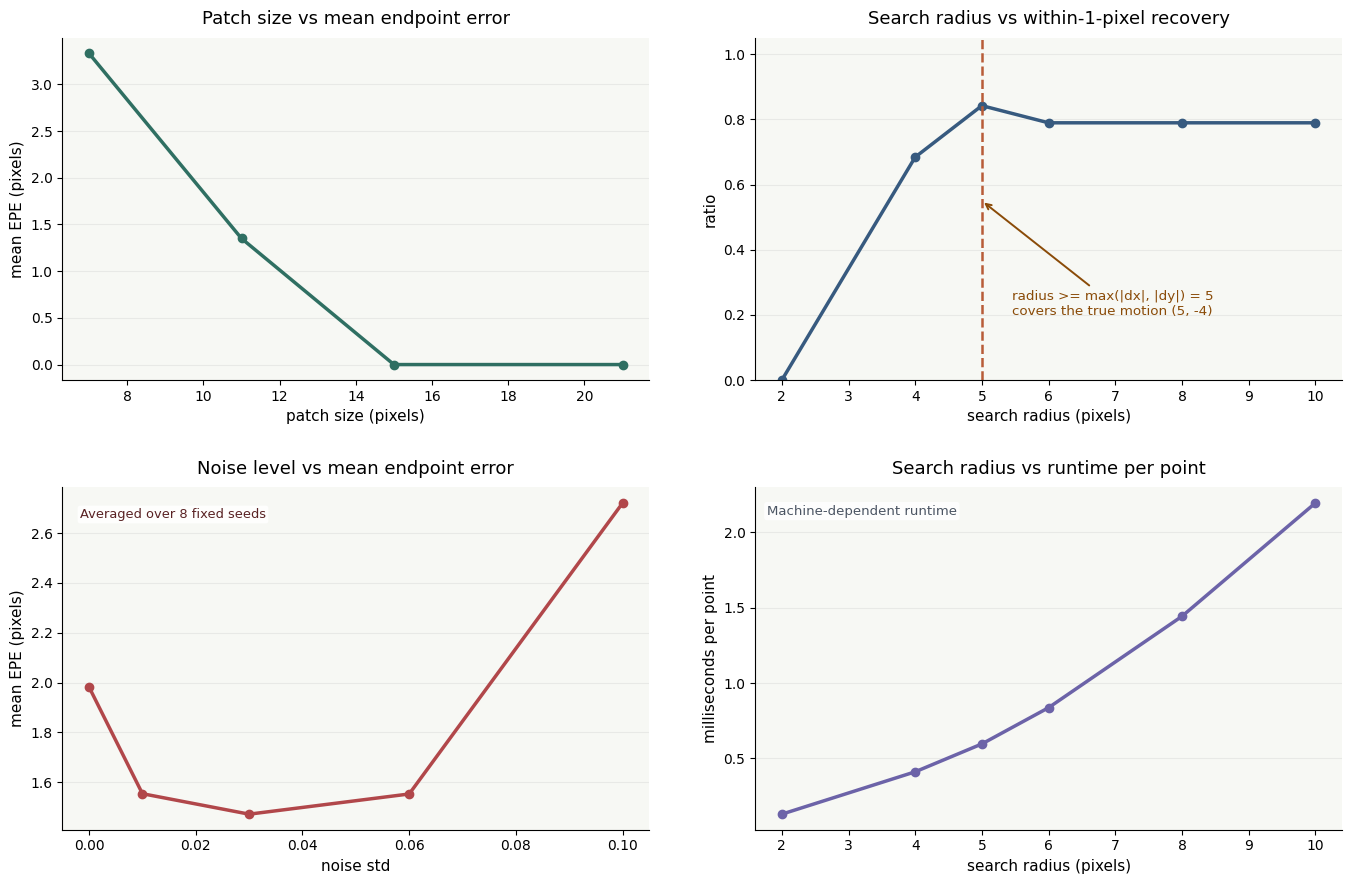

In [7]:
def evaluate_setting(dx=5, dy=-4, noise_std=0.015, patch_size=11, search_radius=8, seed=123):
    f1, f2, gt = make_synthetic_pair(dx=dx, dy=dy, noise_std=noise_std, seed=seed)
    base_points = sample_textured_points(f1, patch_size=11, stride=12, threshold=0.08)
    points = filter_trackable_points(base_points, f1.shape, patch_size=patch_size, search_radius=search_radius)
    start = time.perf_counter()
    est = estimate_sparse_motion(f1, f2, points, patch_size=patch_size, search_radius=search_radius)
    elapsed_ms = 1000.0 * (time.perf_counter() - start)
    summary = summarize_motion_metrics(est, gt)
    summary["ms_per_point"] = elapsed_ms / max(len(points), 1)
    summary["num_points"] = len(points)
    return summary


patch_sizes = [7, 11, 15, 21]
search_radii = [2, 4, 5, 6, 8, 10]
noise_levels = [0.00, 0.01, 0.03, 0.06, 0.10]
noise_seeds = [101, 202, 303, 404, 505, 606, 707, 808]
required_radius = max(abs(int(gt_motion[0])), abs(int(gt_motion[1])))

patch_results = [evaluate_setting(patch_size=p, search_radius=8, noise_std=0.015, seed=321) for p in patch_sizes]
radius_results = [evaluate_setting(patch_size=11, search_radius=r, noise_std=0.015, seed=321) for r in search_radii]
noise_results = []
for noise_std in noise_levels:
    per_seed = [evaluate_setting(patch_size=11, search_radius=8, noise_std=noise_std, seed=seed) for seed in noise_seeds]
    noise_results.append(
        {
            "noise_std": noise_std,
            "mean_epe": float(np.mean([item["mean_epe"] for item in per_seed])),
            "within_1px_ratio": float(np.mean([item["within_1px_ratio"] for item in per_seed])),
        }
    )

fig, axes = plt.subplots(2, 2, figsize=(13.4, 8.8), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.04, h_pad=0.08, hspace=0.08, wspace=0.08)
axes = axes.ravel()

axes[0].plot(patch_sizes, [item["mean_epe"] for item in patch_results], marker="o", color="#2f6f62", linewidth=2.5)
axes[0].set_title("Patch size vs mean endpoint error", pad=10)
axes[0].set_xlabel("patch size (pixels)")
axes[0].set_ylabel("mean EPE (pixels)")

axes[1].plot(search_radii, [item["within_1px_ratio"] for item in radius_results], marker="o", color="#375a7f", linewidth=2.5)
axes[1].axvline(required_radius, color="#b85c38", linestyle="--", linewidth=1.8)
axes[1].annotate(
    "radius >= max(|dx|, |dy|) = 5\ncovers the true motion (5, -4)",
    xy=(required_radius, 0.55),
    xytext=(5.45, 0.2),
    fontsize=9.7,
    color="#8a4b08",
    arrowprops=dict(arrowstyle="->", color="#8a4b08", linewidth=1.4),
)
axes[1].set_title("Search radius vs within-1-pixel recovery", pad=10)
axes[1].set_xlabel("search radius (pixels)")
axes[1].set_ylabel("ratio")
axes[1].set_ylim(0, 1.05)

axes[2].plot(
    [item["noise_std"] for item in noise_results],
    [item["mean_epe"] for item in noise_results],
    marker="o",
    color="#b1474a",
    linewidth=2.5,
)
axes[2].set_title("Noise level vs mean endpoint error", pad=10)
axes[2].set_xlabel("noise std")
axes[2].set_ylabel("mean EPE (pixels)")
axes[2].text(
    0.03,
    0.94,
    f"Averaged over {len(noise_seeds)} fixed seeds",
    transform=axes[2].transAxes,
    ha="left",
    va="top",
    fontsize=9.4,
    color="#5a2324",
    bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor="none", alpha=0.88),
)

axes[3].plot(search_radii, [item["ms_per_point"] for item in radius_results], marker="o", color="#6c63a8", linewidth=2.5)
axes[3].set_title("Search radius vs runtime per point", pad=10)
axes[3].set_xlabel("search radius (pixels)")
axes[3].set_ylabel("milliseconds per point")
axes[3].text(
    0.02,
    0.95,
    "Machine-dependent runtime",
    transform=axes[3].transAxes,
    ha="left",
    va="top",
    fontsize=9.5,
    color="#4b5563",
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85),
)

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.tick_params(labelsize=10)

save_figure(fig, "05-parameter-sweeps.png")
plt.show()


## Failure cases

A basic local matcher has clear blind spots. We will demonstrate two of the most important ones.

1. **Repetitive texture**: many candidate patches look equally good.
2. **Motion outside the search radius**: the correct answer is never even evaluated.

Both panels below are executable diagnostics with the same ingredients as the successful single-point demo.
What changes is the geometry of the problem: either the cost surface becomes ambiguous, or the true motion falls outside the searched displacement range.
The large-motion example explicitly labels that the true target is outside the searched region, so the incorrect match is a boundary-limited failure rather than a bug in the plot.


Failure A: repetitive texture ambiguity: estimated = (-4, -8), true = (4, 0), best SSD = 0.0000


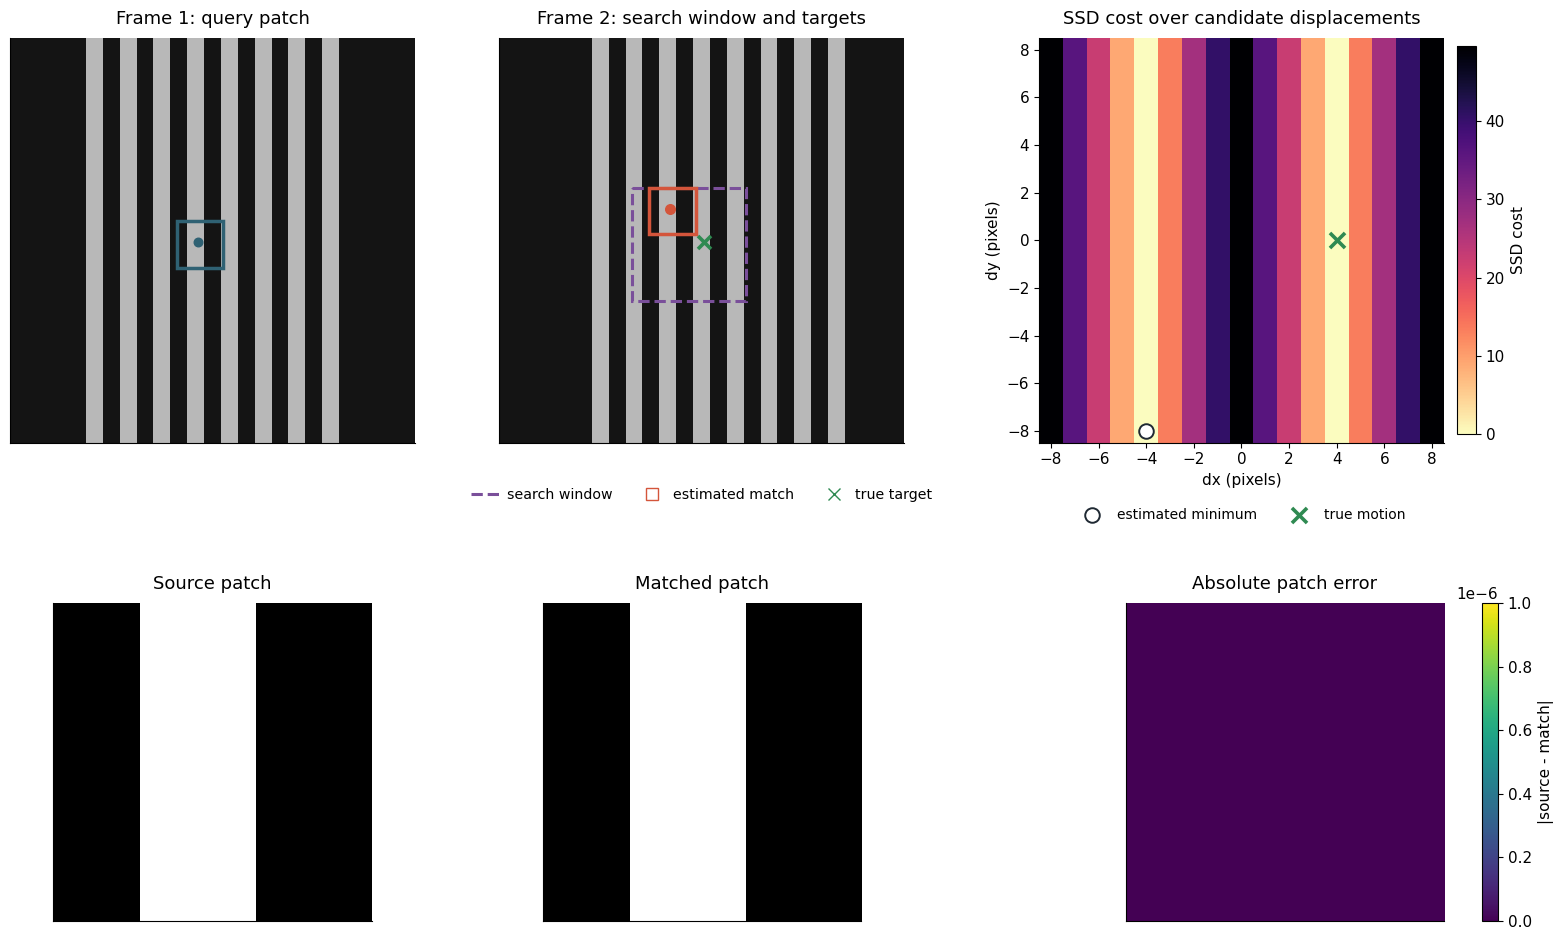

Repeated stripes create nearly identical candidate patches at several displacements, so the SSD minimum is ambiguous even when the true motion lies inside the search window.
Failure B: motion beyond the search radius: estimated = (5, -3), true = (11, -7), best SSD = 4.5418
True target is outside the searched region, so patch matching cannot recover it.


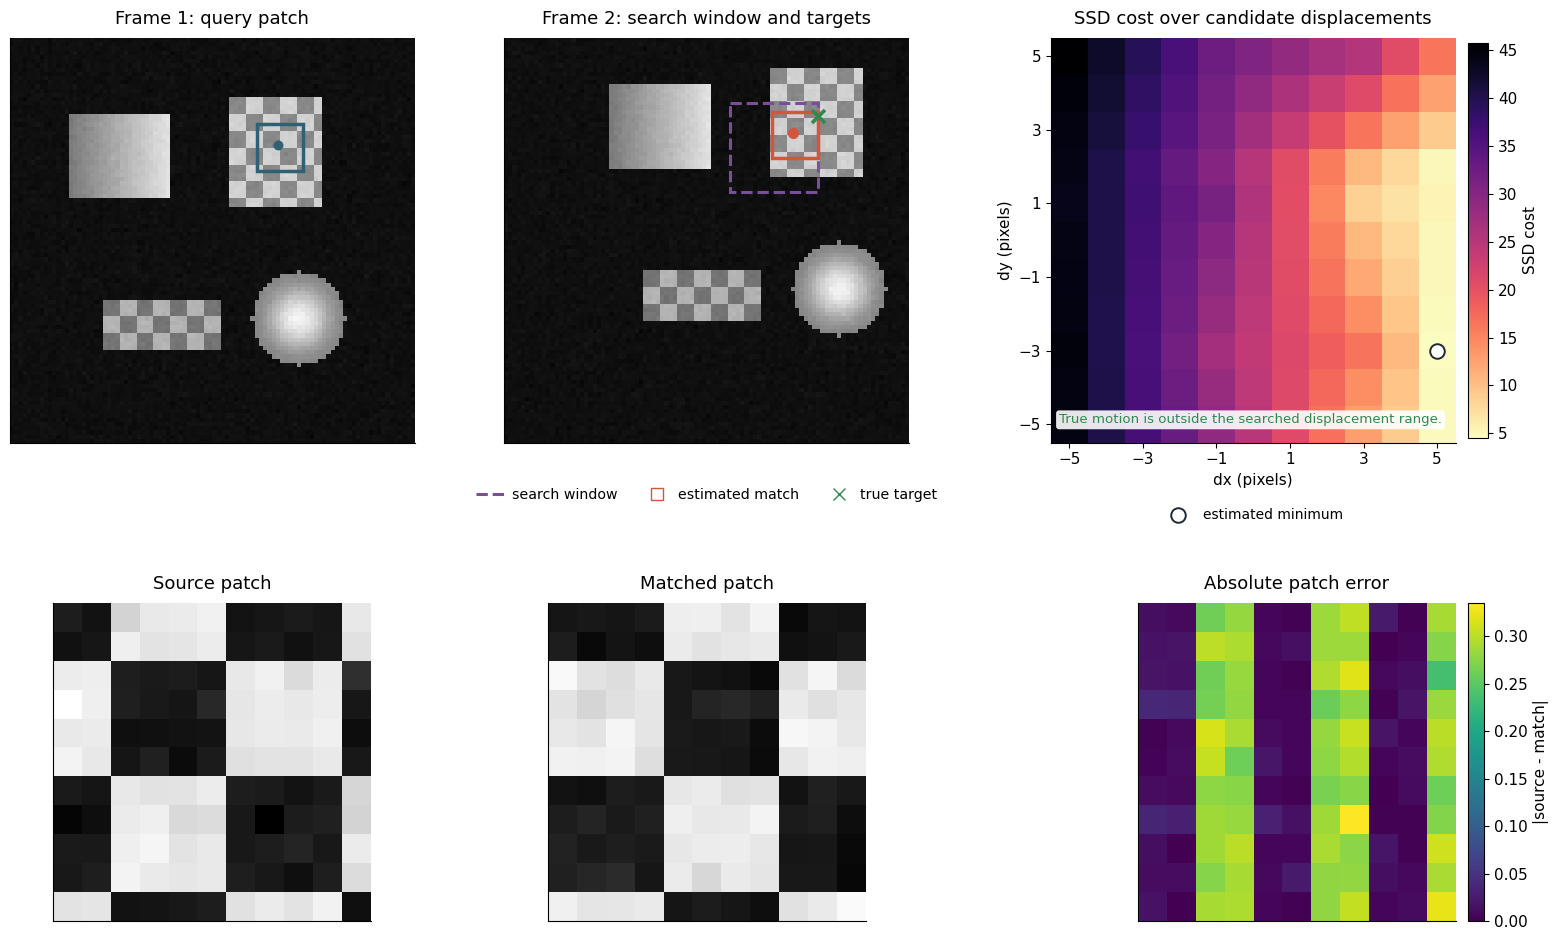

The true target is outside the searched region, so patch matching cannot recover it and instead returns the best in-range candidate.


In [8]:
def make_repetitive_texture_pair(dx=4, dy=0, size=96):
    frame1 = np.full((size, size), 0.08, dtype=float)
    for x0 in range(18, 78, 8):
        frame1[:, x0 : x0 + 4] = 0.72
    frame2 = shift_image_integer(frame1, dx=dx, dy=dy, fill_value=0.08)
    return frame1, frame2, np.array([dx, dy], dtype=int)


def draw_failure_demo(frame1, frame2, point_xy, gt_motion, patch_size, search_radius, title, takeaway, save_name, note=None):
    result = estimate_patch_motion(frame1, frame2, point_xy, patch_size=patch_size, search_radius=search_radius)
    draw_patch_matching_diagnostic(
        frame1,
        frame2,
        point_xy,
        gt_motion,
        result,
        patch_size,
        search_radius,
        title=title,
        save_name=save_name,
        note=note,
    )
    print(takeaway)


repetitive_f1, repetitive_f2, repetitive_gt = make_repetitive_texture_pair(dx=4, dy=0)
draw_failure_demo(
    repetitive_f1,
    repetitive_f2,
    point_xy=(44, 48),
    gt_motion=repetitive_gt,
    patch_size=11,
    search_radius=8,
    title="Failure A: repetitive texture ambiguity",
    takeaway="Repeated stripes create nearly identical candidate patches at several displacements, so the SSD minimum is ambiguous even when the true motion lies inside the search window.",
    save_name="06-failure-repetitive-texture.png",
)

large_f1, large_f2, large_gt = make_synthetic_pair(dx=11, dy=-7, noise_std=0.01, seed=11)
draw_failure_demo(
    large_f1,
    large_f2,
    point_xy=(63, 25),
    gt_motion=large_gt,
    patch_size=11,
    search_radius=5,
    title="Failure B: motion beyond the search radius",
    takeaway="The true target is outside the searched region, so patch matching cannot recover it and instead returns the best in-range candidate.",
    save_name="07-failure-large-motion.png",
    note="True target is outside the searched region, so patch matching cannot recover it.",
)


## Limitations and takeaway

Patch matching works well when:

- motion is moderate,
- the search window covers the true displacement,
- local texture is distinctive,
- and noise is not too strong.

It struggles when texture is ambiguous, motion is too large, illumination changes, or the underlying motion varies strongly inside one patch.
Those limitations are exactly why more advanced methods such as Lucas-Kanade, Horn-Schunck style optical flow, pyramidal search, and learned flow estimators exist.


## Reproducibility

- All random choices use a fixed seed.
- The main synthetic example uses integer translation so the ground truth is unambiguous.
- The notebook is organized so you can run it top to bottom without hidden state.

If you want an extra exercise, try replacing the global translation with rotation or locally varying motion and see where the baseline breaks first.
